In [2]:
import sys
sys.path.append("..")  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import FIG_DIR, PROCESSED_DIR

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_parquet(PROCESSED_DIR / "hourly.parquet")
print(df.shape)
df.head()

(66456, 6)


,demand_mw,temp_f,humidity_pct,wind_mph,cloud_pct,timestamp_local
timestamp_utc,,,,,,
2019-01-01 00:00:00+00:00,19586.0,39.63,94.70,9.920,100.00,2018-12-31 19:00:00-05:00
2019-01-01 01:00:00+00:00,18891.0,41.05,94.40,11.895,100.00,2018-12-31 20:00:00-05:00
2019-01-01 02:00:00+00:00,18198.0,41.99,94.40,12.700,100.00,2018-12-31 21:00:00-05:00
2019-01-01 03:00:00+00:00,17423.0,43.72,93.50,15.190,97.15,2018-12-31 22:00:00-05:00
2019-01-01 04:00:00+00:00,16613.0,45.22,94.05,14.570,99.10,2018-12-31 23:00:00-05:00


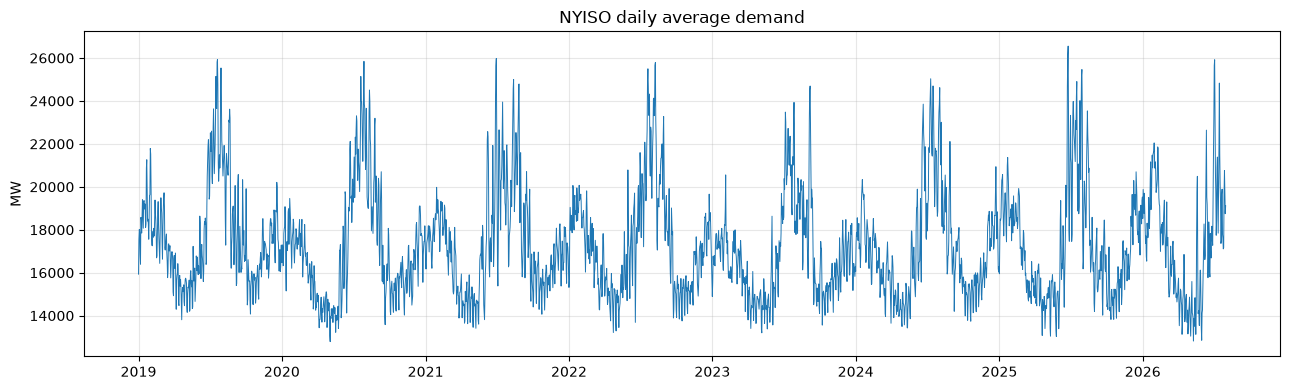

In [3]:
daily = df["demand_mw"].resample("D").mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily.values, linewidth=0.7)
ax.set_title("NYISO daily average demand")
ax.set_ylabel("MW")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_daily_series.png", dpi=130)
plt.show()

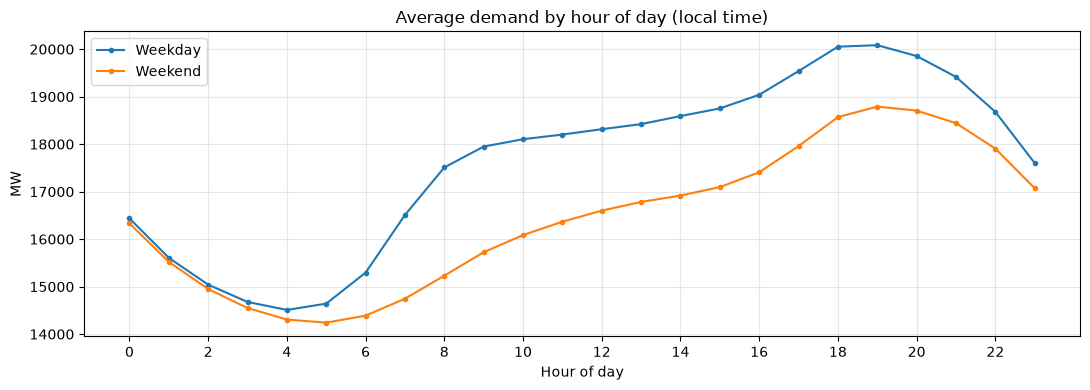

In [4]:
d = df.copy()
d["hour"] = d["timestamp_local"].dt.hour
d["is_weekend"] = d["timestamp_local"].dt.dayofweek >= 5

fig, ax = plt.subplots()
for is_we, label in [(False, "Weekday"), (True, "Weekend")]:
    prof = d.loc[d["is_weekend"] == is_we].groupby("hour")["demand_mw"].mean()
    ax.plot(prof.index, prof.values, marker="o", markersize=3, label=label)

ax.set_title("Average demand by hour of day (local time)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 24, 2))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_daily_profile.png", dpi=130)
plt.show()

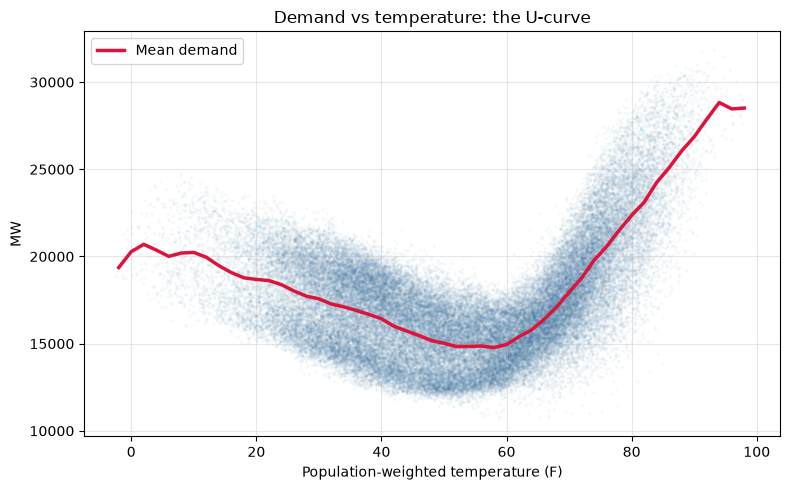

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))


ax.scatter(df["temp_f"], df["demand_mw"], s=2, alpha=0.03, color="steelblue")

bins = np.arange(np.floor(df["temp_f"].min()), np.ceil(df["temp_f"].max()) + 2, 2)
binned = df.groupby(pd.cut(df["temp_f"], bins), observed=True)["demand_mw"].mean()
centers = [iv.mid for iv in binned.index]

ax.plot(centers, binned.values, color="crimson", linewidth=2.5, label="Mean demand")
ax.set_title("Demand vs temperature: the U-curve")
ax.set_xlabel("Population-weighted temperature (F)")
ax.set_ylabel("MW")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_demand_vs_temp.png", dpi=130)
plt.show()

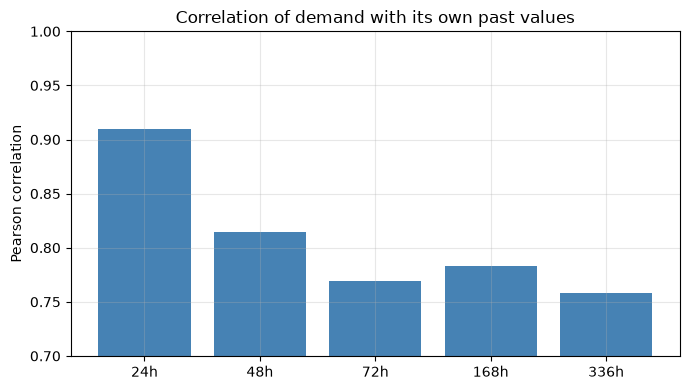

lag_24     0.9094
lag_48     0.8145
lag_72     0.7688
lag_168    0.7835
lag_336    0.7583
Name: demand_mw, dtype: float64


In [6]:
tmp = df[["demand_mw"]].copy()
for lag in [24, 48, 72, 168, 336]:
    tmp[f"lag_{lag}"] = tmp["demand_mw"].shift(lag)

corr = tmp.corr()["demand_mw"].drop("demand_mw")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([c.replace("lag_", "") + "h" for c in corr.index], corr.values, color="steelblue")
ax.set_ylim(0.7, 1.0)
ax.set_title("Correlation of demand with its own past values")
ax.set_ylabel("Pearson correlation")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_lag_correlation.png", dpi=130)
plt.show()

print(corr.round(4))

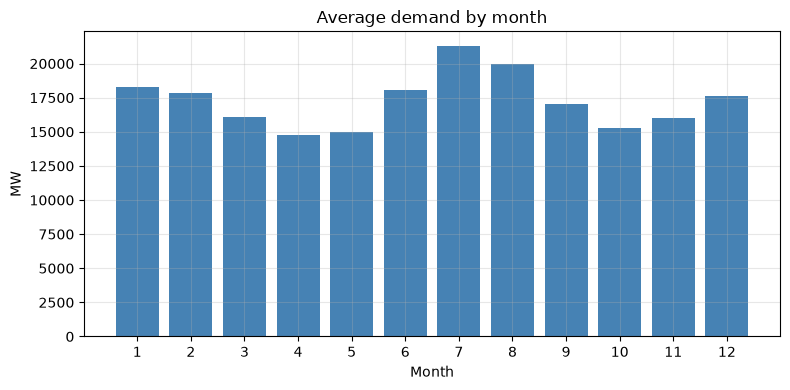


July 4 mean demand: 19143
All July mean demand: 21297


In [7]:
d["month"] = d["timestamp_local"].dt.month
monthly = d.groupby("month")["demand_mw"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly.index, monthly.values, color="steelblue")
ax.set_title("Average demand by month")
ax.set_xlabel("Month")
ax.set_ylabel("MW")
ax.set_xticks(range(1, 13))
fig.tight_layout()
fig.savefig(FIG_DIR / "05_monthly.png", dpi=130)
plt.show()

# Peek at a holiday: does July 4th behave like a weekday or a Sunday?
jul4 = df[(df["timestamp_local"].dt.month == 7) &
          (df["timestamp_local"].dt.day == 4)]
print("\nJuly 4 mean demand:", round(jul4["demand_mw"].mean()))
print("All July mean demand:",
      round(df.loc[df["timestamp_local"].dt.month == 7, "demand_mw"].mean()))